In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
results = pd.read_csv('results.csv')
races = pd.read_csv('races.csv')
qualifying = pd.read_csv('qualifying.csv')
constructors = pd.read_csv('constructors.csv')
drivers = pd.read_csv('drivers.csv')


In [4]:
print(results.head())
print(races.head())
print(qualifying.head())
print(constructors.head())
print(drivers.head())







   resultId  raceId  driverId  constructorId number  grid position  \
0         1      18         1              1     22     1        1   
1         2      18         2              2      3     5        2   
2         3      18         3              3      7     7        3   
3         4      18         4              4      5    11        4   
4         5      18         5              1     23     3        5   

  positionText  positionOrder  points  laps         time milliseconds  \
0            1              1    10.0    58  1:34:50.616      5690616   
1            2              2     8.0    58       +5.478      5696094   
2            3              3     6.0    58       +8.163      5698779   
3            4              4     5.0    58      +17.181      5707797   
4            5              5     4.0    58      +18.014      5708630   

  fastestLap rank fastestLapTime fastestLapSpeed  statusId  
0         39    2       1:27.452         218.300         1  
1         41    3 

In [5]:
print(results.columns)
print(races.columns)
print(qualifying.columns)
print(constructors.columns)
print(drivers.columns)

Index(['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid',
       'position', 'positionText', 'positionOrder', 'points', 'laps', 'time',
       'milliseconds', 'fastestLap', 'rank', 'fastestLapTime',
       'fastestLapSpeed', 'statusId'],
      dtype='object')
Index(['raceId', 'year', 'round', 'circuitId', 'name', 'date', 'time', 'url',
       'fp1_date', 'fp1_time', 'fp2_date', 'fp2_time', 'fp3_date', 'fp3_time',
       'quali_date', 'quali_time', 'sprint_date', 'sprint_time'],
      dtype='object')
Index(['qualifyId', 'raceId', 'driverId', 'constructorId', 'number',
       'position', 'q1', 'q2', 'q3'],
      dtype='object')
Index(['constructorId', 'constructorRef', 'name', 'nationality', 'url'], dtype='object')
Index(['driverId', 'driverRef', 'number', 'code', 'forename', 'surname', 'dob',
       'nationality', 'url'],
      dtype='object')


In [8]:
result_races=pd.merge(results,races,on="raceId")
result_races_drivers=pd.merge(result_races,drivers,on="driverId")
merged_data=pd.merge(result_races_drivers,constructors,on="constructorId")

In [9]:
merged_data.head()

,resultId,raceId,driverId,constructorId,number_x,grid,position,positionText,positionOrder,points,...,code,forename,surname,dob,nationality_x,url_y,constructorRef,name_y,nationality_y,url
0,1,18,1,1,22,1,1,1,1,10.0,...,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,18,2,2,3,5,2,2,2,8.0,...,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,18,3,3,7,7,3,3,3,6.0,...,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,18,4,4,5,11,4,4,4,5.0,...,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,18,5,1,23,3,5,5,5,4.0,...,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren


In [12]:
final_data = merged_data[['raceId', 'year', 'round', 'name_x', 'surname', 'name_y',
                          'grid', 'positionOrder', 'points', 'laps', 'milliseconds']].copy()

final_data.rename(columns={
    'name_x': 'GrandPrix',
    'surname': 'Driver',
    'name_y': 'Constructor',
    'grid': 'QualifyingPosition',
    'positionOrder': 'FinishingPosition'
}, inplace=True)


In [13]:
print(final_data.head())

   raceId  year  round              GrandPrix      Driver Constructor  \
0      18  2008      1  Australian Grand Prix    Hamilton     McLaren   
1      18  2008      1  Australian Grand Prix    Heidfeld  BMW Sauber   
2      18  2008      1  Australian Grand Prix     Rosberg    Williams   
3      18  2008      1  Australian Grand Prix      Alonso     Renault   
4      18  2008      1  Australian Grand Prix  Kovalainen     McLaren   

   QualifyingPosition  FinishingPosition  points  laps milliseconds  
0                   1                  1    10.0    58      5690616  
1                   5                  2     8.0    58      5696094  
2                   7                  3     6.0    58      5698779  
3                  11                  4     5.0    58      5707797  
4                   3                  5     4.0    58      5708630  


In [15]:
final_data.isnull().sum()

raceId                0
year                  0
round                 0
GrandPrix             0
Driver                0
Constructor           0
QualifyingPosition    0
FinishingPosition     0
points                0
laps                  0
milliseconds          0
dtype: int64

In [16]:
final_data.shape

(26759, 11)

In [29]:
final_data.dropna()

,raceId,year,round,GrandPrix,Driver,Constructor,QualifyingPosition,FinishingPosition,points,laps,milliseconds
0,18,2008,1,Australian Grand Prix,Hamilton,McLaren,1,1,10.0,58,5690616
1,18,2008,1,Australian Grand Prix,Heidfeld,BMW Sauber,5,2,8.0,58,5696094
2,18,2008,1,Australian Grand Prix,Rosberg,Williams,7,3,6.0,58,5698779
3,18,2008,1,Australian Grand Prix,Alonso,Renault,11,4,5.0,58,5707797
4,18,2008,1,Australian Grand Prix,Kovalainen,McLaren,3,5,4.0,58,5708630
...,...,...,...,...,...,...,...,...,...,...,...
26754,1144,2024,24,Abu Dhabi Grand Prix,Magnussen,Haas F1 Team,14,16,0.0,57,\N
26755,1144,2024,24,Abu Dhabi Grand Prix,Lawson,RB F1 Team,12,17,0.0,55,\N
26756,1144,2024,24,Abu Dhabi Grand Prix,Bottas,Sauber,9,18,0.0,30,\N
26757,1144,2024,24,Abu Dhabi Grand Prix,Colapinto,Williams,20,19,0.0,26,\N


In [26]:
final_data.shape

(26759, 11)

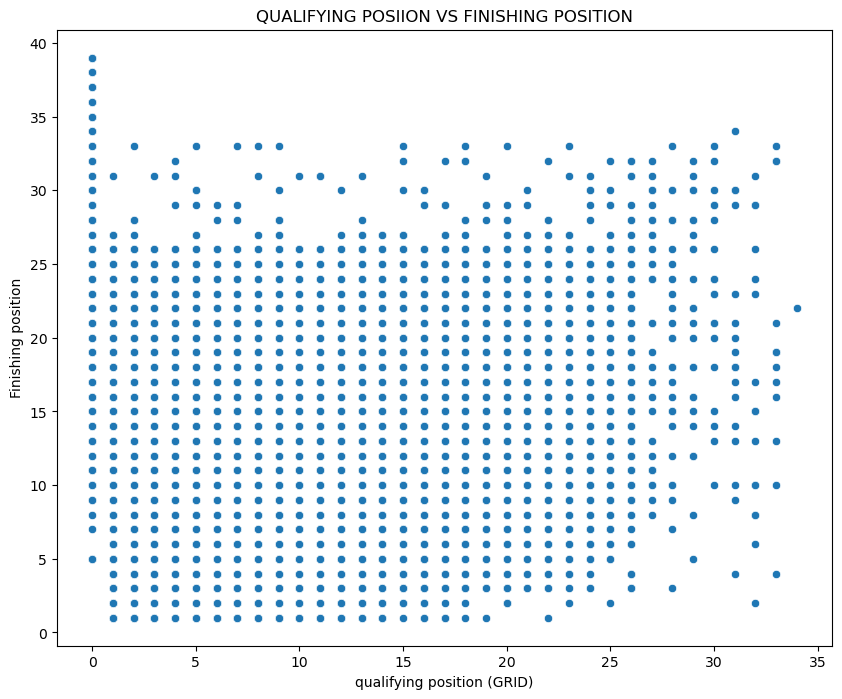

In [32]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=final_data,x="QualifyingPosition",y="FinishingPosition")
plt.title("QUALIFYING POSIION VS FINISHING POSITION")
plt.xlabel("qualifying position (GRID)")
plt.ylabel("Finishing position")
plt.show()

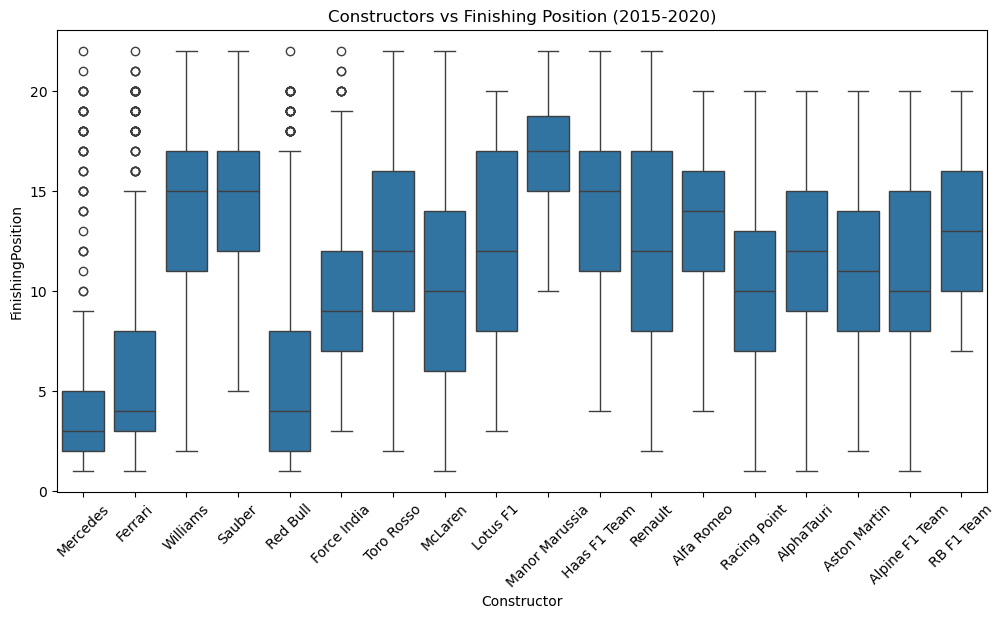

In [36]:
recent_data = final_data[final_data['year'] >= 2015]
plt.figure(figsize=(12, 6))
sns.boxplot(data=recent_data, x='Constructor', y='FinishingPosition')
plt.title('Constructors vs Finishing Position (2015-2020)')
plt.xticks(rotation=45)
plt.show()


In [37]:
final_data.to_csv("f1_cleaned_data.csv",index=False)